# Evaluation Expansion

## Load Data

In [1]:
# import dependencies
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
except Exception as exc:
    XGBRegressor = None
    print('XGBoost import failed:', exc)

try:
    from catboost import CatBoostRegressor
except Exception as exc:
    CatBoostRegressor = None
    print('CatBoost import failed:', exc)

In [2]:
# paths and constants
target_col = 'ClosePrice'

cleaned_train_path = 'data_clean/cleaned_train_not_encoded.csv'
cleaned_test_path = 'data_clean/cleaned_test_not_encoded.csv'
output_dir = './final_model_outputs'

leakage_cols = [
    'ListPrice',
    'OriginalListPrice',
    'DaysOnMarket',
    'PurchaseContractDate'
]

In [3]:
# load cleaned train/test data
train = pd.read_csv(cleaned_train_path)
test = pd.read_csv(cleaned_test_path)

train['CloseDate'] = pd.to_datetime(train['CloseDate'], errors='coerce')
test['CloseDate'] = pd.to_datetime(test['CloseDate'], errors='coerce')
train['CloseMonth'] = train['CloseMonth'].astype(str)
test['CloseMonth'] = test['CloseMonth'].astype(str)

# keep training before June 2026 and test data in June 2026
train = train[train['CloseDate'] < '2026-06-01'].copy()
test = test[(test['CloseDate'] >= '2026-06-01') & (test['CloseDate'] < '2026-07-01')].copy()

# keep only rows with a usable positive target value
train[target_col] = pd.to_numeric(train[target_col], errors='coerce')
test[target_col] = pd.to_numeric(test[target_col], errors='coerce')
train = train[train[target_col] > 0].copy()
test = test[test[target_col] > 0].copy()

train = train.sort_values('CloseDate').reset_index(drop=True)
test = test.sort_values('CloseDate').reset_index(drop=True)

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Train date range:', train['CloseDate'].min(), 'to', train['CloseDate'].max())
print('Test date range:', test['CloseDate'].min(), 'to', test['CloseDate'].max())
print('Train months:', sorted(train['CloseMonth'].unique()))
print('Test months:', sorted(test['CloseMonth'].unique()))

Train shape: (51267, 37)
Test shape: (12856, 37)
Train date range: 2026-01-01 00:00:00 to 2026-05-31 00:00:00
Test date range: 2026-06-01 00:00:00 to 2026-06-30 00:00:00
Train months: ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05']
Test months: ['2026-06']


## Feature Set

In [4]:
# add simple engineered property features
def add_property_features(df):
    df = df.copy()
    
    for col in ['YearBuilt', 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    sale_year = pd.to_datetime(df['CloseDate'], errors='coerce').dt.year
    
    if 'YearBuilt' in df.columns:
        df['PropertyAge'] = (sale_year - df['YearBuilt']).clip(lower=0)
    
    if {'BedroomsTotal', 'BathroomsTotalInteger'}.issubset(df.columns):
        bathrooms = df['BathroomsTotalInteger'].replace(0, np.nan)
        df['BedBathRatio'] = (df['BedroomsTotal'] / bathrooms).replace([np.inf, -np.inf], np.nan)
    
    if {'LivingArea', 'BedroomsTotal'}.issubset(df.columns):
        bedrooms = df['BedroomsTotal'].replace(0, np.nan)
        df['LivingAreaPerBedroom'] = (df['LivingArea'] / bedrooms).replace([np.inf, -np.inf], np.nan)
    
    return df


train = add_property_features(train)
test = add_property_features(test)

In [5]:
# choose the same general feature set used in the advanced model notebook
baseline_numeric_features = [
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeAcres',
    'YearBuilt',
    'GarageSpaces',
    'ParkingTotal',
    'AssociationFee'
]

missing_indicator_cols = [col for col in train.columns if col.endswith('_missing')]

engineered_features = [
    'PropertyAge',
    'BedBathRatio',
    'LivingAreaPerBedroom'
]

location_features = [
    'City',
    'CountyOrParish',
    'PostalCode',
    'MLSAreaMajor',
    'HighSchoolDistrict',
    'SchoolDistrict'
]

non_feature_cols = [target_col, 'CloseDate', 'CloseMonth']
drop_cols = non_feature_cols + leakage_cols

candidate_features = (
    baseline_numeric_features
    + missing_indicator_cols
    + engineered_features
    + location_features
)

feature_cols = [
    col for col in candidate_features
    if col in train.columns and col in test.columns and col not in drop_cols
]
feature_cols = list(dict.fromkeys(feature_cols))

leakage_found = [col for col in leakage_cols if col in train.columns or col in test.columns]
if leakage_found:
    print('Leakage columns found and excluded:', leakage_found)
else:
    print('No leakage columns found in the cleaned data.')

if 'SchoolDistrict' not in feature_cols:
    print('SchoolDistrict column not found, so it is not included.')

print('Feature columns:')
print(feature_cols)
print('Number of features before encoding:', len(feature_cols))

No leakage columns found in the cleaned data.
SchoolDistrict column not found, so it is not included.
Feature columns:
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeAcres_missing', 'GarageSpaces_missing', 'AssociationFee_missing', 'PropertyAge', 'BedBathRatio', 'LivingAreaPerBedroom', 'City', 'CountyOrParish', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict']
Number of features before encoding: 19


In [6]:
# create feature matrices and target vectors
X_train = train[feature_cols].copy()
y_train = train[target_col].copy()

X_test = test[feature_cols].copy()
y_test = test[target_col].copy()

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (51267, 19)
X_test shape: (12856, 19)
y_train shape: (51267,)
y_test shape: (12856,)


## Evaluation Metrics

In [7]:
# evaluate predictions with regular error metrics and percentage error metrics
def evaluate_predictions(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    
    nonzero_mask = y_true != 0
    if nonzero_mask.sum() == 0:
        mape = np.nan
        mdape = np.nan
    else:
        ape = np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask]) * 100
        mape = np.mean(ape)
        mdape = np.median(ape)
    
    return {
        'Test R²': r2_score(y_true, y_pred),
        'Test MAE': mean_absolute_error(y_true, y_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'Test MAPE': mape,
        'Test MdAPE': mdape
    }


def fit_and_evaluate_model(model_name, model, X_train, y_train, X_test, y_test, preprocessor):
    model_pipeline = Pipeline(steps=[
        ('preprocess', clone(preprocessor)),
        ('model', model)
    ])
    
    model_pipeline.fit(X_train, y_train)
    test_pred = model_pipeline.predict(X_test)
    metrics = evaluate_predictions(y_test, test_pred)
    
    row = {'Model': model_name, **metrics}
    return row, model_pipeline, test_pred

## Preprocessing

The preprocessing is kept simple. Numeric columns use median imputation and scaling. Categorical columns are filled with `Unknown` and one-hot encoded with unknown categories ignored.

In [8]:
# split numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = [col for col in X_train.columns if col not in numeric_cols]

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

transformers = [
    ('num', numeric_pipeline, numeric_cols)
]

if categorical_cols:
    transformers.append(('cat', categorical_pipeline, categorical_cols))

preprocessor = ColumnTransformer(transformers=transformers)

print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)

Numeric columns: ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeAcres_missing', 'GarageSpaces_missing', 'AssociationFee_missing', 'PropertyAge', 'BedBathRatio', 'LivingAreaPerBedroom']
Categorical columns: ['City', 'CountyOrParish', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict']


## Models to Compare

In [9]:
# set up the models
models_to_compare = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=20,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

if XGBRegressor is not None:
    models_to_compare['XGBoost'] = XGBRegressor(
        objective='reg:squarederror',
        max_depth=5,
        learning_rate=0.10,
        n_estimators=500,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
else:
    print('XGBoost is not installed, so it will be skipped.')

if CatBoostRegressor is not None:
    models_to_compare['CatBoost'] = CatBoostRegressor(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        random_seed=42,
        verbose=0,
        allow_writing_files=False
    )
else:
    print('CatBoost is not installed, so it will be skipped.')

list(models_to_compare.keys())

['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'CatBoost']

In [10]:
# train each model and collect test predictions
results = []
fitted_models = {}
test_predictions = {}

for model_name, model in models_to_compare.items():
    print('Training', model_name)
    row, fitted_model, test_pred = fit_and_evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        preprocessor
    )
    
    results.append(row)
    fitted_models[model_name] = fitted_model
    test_predictions[model_name] = test_pred

print('Done')

Training Linear Regression
Training Decision Tree
Training Random Forest
Training XGBoost
Training CatBoost
Done


## Metrics Summary Table

In [11]:
# create and save the metrics summary
os.makedirs(output_dir, exist_ok=True)

metrics_summary = pd.DataFrame(results)
metrics_summary = metrics_summary.sort_values(['Test MdAPE', 'Test MAPE']).reset_index(drop=True)

metrics_summary.to_csv(os.path.join(output_dir, 'metrics_summary.csv'), index=False)

metrics_summary_display = metrics_summary.copy()
metrics_summary_display['Test R²'] = metrics_summary_display['Test R²'].round(3)
metrics_summary_display['Test MAE'] = metrics_summary_display['Test MAE'].round(0)
metrics_summary_display['Test RMSE'] = metrics_summary_display['Test RMSE'].round(0)
metrics_summary_display['Test MAPE'] = metrics_summary_display['Test MAPE'].round(2)
metrics_summary_display['Test MdAPE'] = metrics_summary_display['Test MdAPE'].round(2)

metrics_summary_display

,Model,Test R²,Test MAE,Test RMSE,Test MAPE,Test MdAPE
0,XGBoost,0.852,224815.0,400200.0,19.04,12.91
1,Random Forest,0.789,261969.0,477869.0,21.72,13.10
2,CatBoost,0.820,262212.0,441755.0,23.44,15.98
3,Linear Regression,0.801,284332.0,463996.0,26.44,18.84
4,Decision Tree,0.671,359748.0,597044.0,33.53,20.43


## Plot Model Comparison

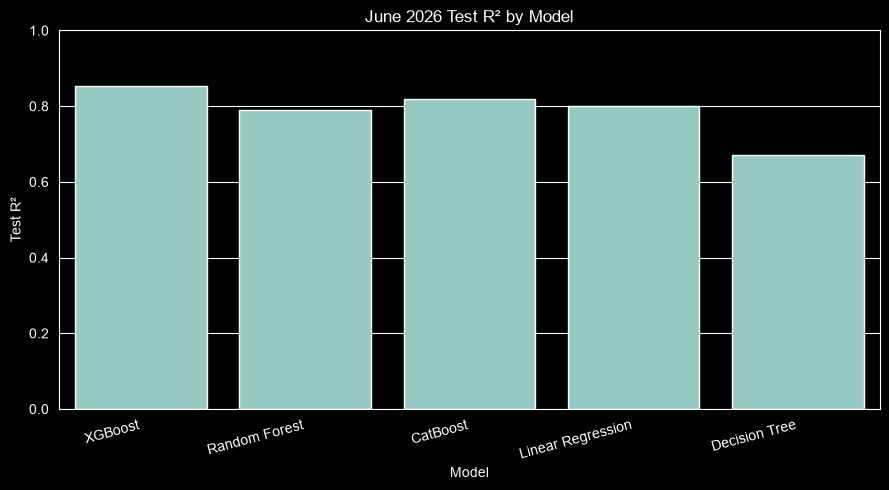

In [12]:
# bar plot of test R squared by model
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_summary, x='Model', y='Test R²')
plt.ylim(0, 1.0)
plt.title('June 2026 Test R² by Model')
plt.xlabel('Model')
plt.ylabel('Test R²')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

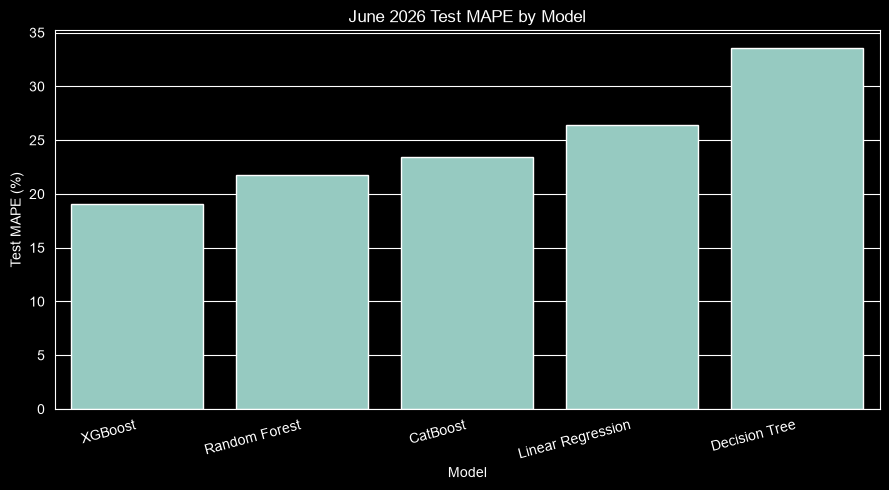

In [13]:
# bar plot of test MAPE by model
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_summary, x='Model', y='Test MAPE')
plt.title('June 2026 Test MAPE by Model')
plt.xlabel('Model')
plt.ylabel('Test MAPE (%)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

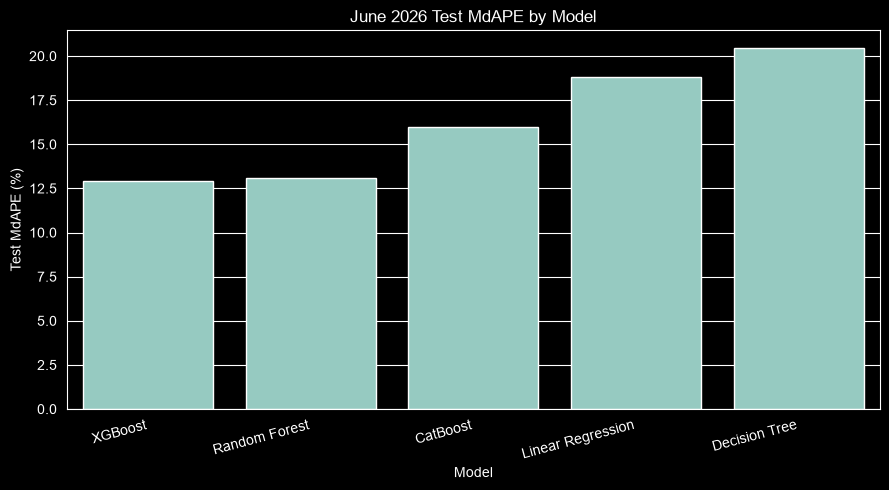

In [14]:
# bar plot of test MdAPE by model
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_summary, x='Model', y='Test MdAPE')
plt.title('June 2026 Test MdAPE by Model')
plt.xlabel('Model')
plt.ylabel('Test MdAPE (%)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Price Band Evaluation

In [15]:
# create price bands from the true June 2026 close price
price_bins = [0, 500000, 1000000, 2000000, 5000000, np.inf]
price_labels = ['Under $500K', '$500K-$1M', '$1M-$2M', '$2M-$5M', 'Over $5M']

price_band_base = pd.DataFrame({
    'ClosePrice': y_test.values,
    'Price Band': pd.cut(y_test.values, bins=price_bins, labels=price_labels, include_lowest=True)
})

price_band_base['Price Band'].value_counts().sort_index()

Price Band
Under $500K    1817
$500K-$1M      5330
$1M-$2M        3949
$2M-$5M        1516
Over $5M        244
Name: count, dtype: int64

In [16]:
# evaluate XGBoost and CatBoost by price band
price_band_models = [model for model in ['XGBoost', 'CatBoost'] if model in test_predictions]
price_band_rows = []

for model_name in price_band_models:
    band_df = price_band_base.copy()
    band_df['Prediction'] = test_predictions[model_name]
    
    for band_name, group in band_df.groupby('Price Band', observed=False):
        if len(group) == 0:
            continue
        band_metrics = evaluate_predictions(group['ClosePrice'], group['Prediction'])
        price_band_rows.append({
            'Model': model_name,
            'Price Band': band_name,
            'Count': len(group),
            'MAE': band_metrics['Test MAE'],
            'MAPE': band_metrics['Test MAPE'],
            'MdAPE': band_metrics['Test MdAPE']
        })

price_band_results = pd.DataFrame(price_band_rows)

price_band_display = price_band_results.copy()
price_band_display['MAE'] = price_band_display['MAE'].round(0)
price_band_display['MAPE'] = price_band_display['MAPE'].round(2)
price_band_display['MdAPE'] = price_band_display['MdAPE'].round(2)

price_band_display

,Model,Price Band,Count,MAE,MAPE,MdAPE
0,XGBoost,Under $500K,1817,116153.0,32.25,17.90
1,XGBoost,$500K-$1M,5330,124894.0,16.95,11.62
2,XGBoost,$1M-$2M,3949,224307.0,15.82,11.94
3,XGBoost,$2M-$5M,1516,551821.0,18.83,15.69
4,XGBoost,Over $5M,244,1193177.0,19.78,16.55
5,CatBoost,Under $500K,1817,156840.0,43.35,28.80
6,CatBoost,$500K-$1M,5330,156341.0,21.46,14.80
7,CatBoost,$1M-$2M,3949,257675.0,18.19,13.97
8,CatBoost,$2M-$5M,1516,596452.0,20.37,17.46
9,CatBoost,Over $5M,244,1356325.0,22.42,18.78


For XGBoost, the `$500K-$1M` and `$1M-$2M` bands had the lowest percentage errors, with MAPE around 16-17% and MdAPE around 11-12%. The `Under $500K` group had the lowest dollar MAE but the highest percentage error, because the same dollar miss is larger relative to a lower sale price. The `$2M-$5M` and `Over $5M` bands had much larger dollar errors and somewhat higher percentage errors, which makes sense because there are fewer high-priced examples and more variation between luxury homes. CatBoost was worse than XGBoost in every price band here.

## Choose Final Model

XGBoost is the final model. It had the best `Test R²`, lowest MAE/RMSE, and lowest MAPE/MdAPE on the June 2026 test set. CatBoost was tested as the extra model, but it did not beat XGBoost overall or within the price bands, so there is not a good reason to switch away from XGBoost.

In [17]:
# choose the final model
if 'XGBoost' in metrics_summary['Model'].values:
    final_model_name = 'XGBoost'
else:
    final_model_name = metrics_summary.iloc[0]['Model']

if {'XGBoost', 'CatBoost'}.issubset(set(metrics_summary['Model'])):
    xgb_row = metrics_summary[metrics_summary['Model'] == 'XGBoost'].iloc[0]
    cat_row = metrics_summary[metrics_summary['Model'] == 'CatBoost'].iloc[0]
    
    catboost_clearly_better = (
        (cat_row['Test MdAPE'] <= xgb_row['Test MdAPE'] - 0.50)
        and (cat_row['Test R²'] >= xgb_row['Test R²'] - 0.01)
    )
    
    if catboost_clearly_better:
        final_model_name = 'CatBoost'

final_model_metrics = metrics_summary[metrics_summary['Model'] == final_model_name].iloc[0]

print('Final model:', final_model_name)
print('Test R²:', round(final_model_metrics['Test R²'], 3))
print('Test MAE:', round(final_model_metrics['Test MAE'], 0))
print('Test RMSE:', round(final_model_metrics['Test RMSE'], 0))
print('Test MAPE:', round(final_model_metrics['Test MAPE'], 2))
print('Test MdAPE:', round(final_model_metrics['Test MdAPE'], 2))

Final model: XGBoost
Test R²: 0.852
Test MAE: 224815.0
Test RMSE: 400200.0
Test MAPE: 19.04
Test MdAPE: 12.91


## Save Final Model

In [18]:
# refit and save the final model pipeline
final_model_pipeline = Pipeline(steps=[
    ('preprocess', clone(preprocessor)),
    ('model', clone(models_to_compare[final_model_name]))
])

final_model_pipeline.fit(X_train, y_train)

final_model_path = os.path.join(output_dir, 'final_model.joblib')
joblib.dump(final_model_pipeline, final_model_path)

feature_info = {
    'features': feature_cols,
    'target': target_col,
    'test_month': '2026-06',
    'final_model': final_model_name
}

feature_info_path = os.path.join(output_dir, 'final_model_features.json')
with open(feature_info_path, 'w') as f:
    json.dump(feature_info, f, indent=2)

final_note = f"""# Final Model Note

Model name: {final_model_name}

Feature set used: baseline numeric features, missing indicators, engineered property features, and location/school features that existed in the data.

Test month: 2026-06

Main June 2026 test metrics:
- Test R²: {final_model_metrics['Test R²']:.3f}
- Test MAE: {final_model_metrics['Test MAE']:.0f}
- Test RMSE: {final_model_metrics['Test RMSE']:.0f}
- Test MAPE: {final_model_metrics['Test MAPE']:.2f}%
- Test MdAPE: {final_model_metrics['Test MdAPE']:.2f}%
"""

final_note_path = os.path.join(output_dir, 'final_model_note.md')
with open(final_note_path, 'w') as f:
    f.write(final_note)

print('Saved final model to:', final_model_path)
print('Saved feature information to:', feature_info_path)
print('Saved final model note to:', final_note_path)

Saved final model to: ./final_model_outputs/final_model.joblib
Saved feature information to: ./final_model_outputs/final_model_features.json
Saved final model note to: ./final_model_outputs/final_model_note.md
